# Praktikum Hierarchical Clustering

**Nama** : Christina Adelia Sitinjak  
**NIM** : 42324056 

Hierarchical Clustering adalah metode klasterisasi yang mengelompokkan data dalam bentuk hierarki, dengan cara menggabungkan atau memisahkan klaster secara bertahap. Hasilnya digambar sebagai **dendrogram** (diagram pohon). Percobaan pertama memakai dataset sederhana (6 titik) supaya mudah dipahami, lalu percobaan kedua memakai dataset **Mall Customers**.

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


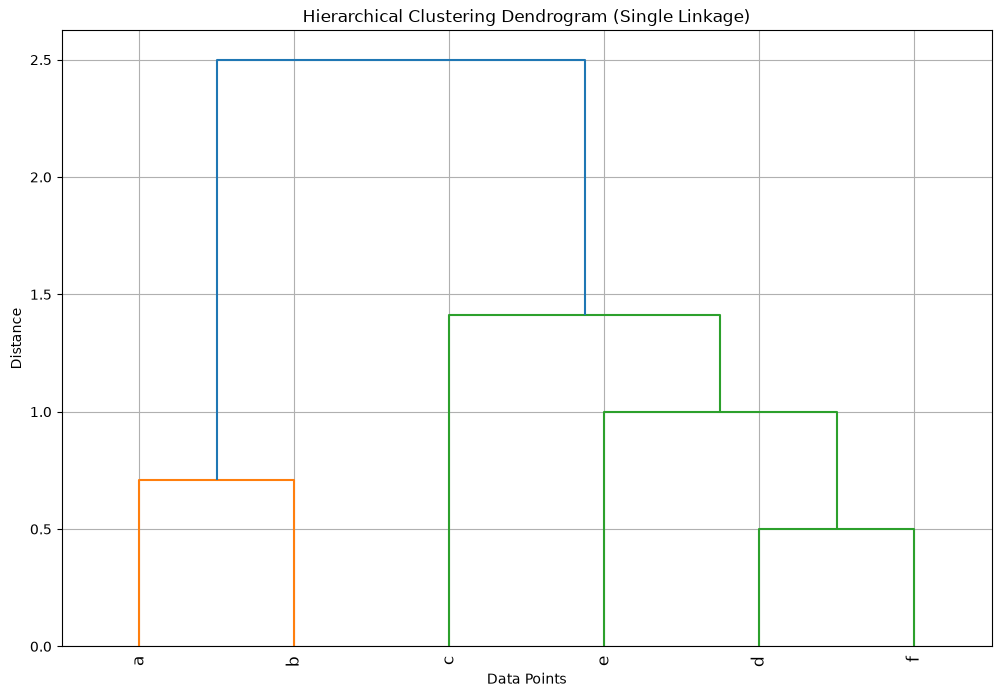

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5]  # f
])

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                           columns=['a', 'b', 'c', 'd', 'e', 'f'],
                           index=['a', 'b', 'c', 'd', 'e', 'f'])

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

#### Penjelasan:
Kode di atas untuk membuat dataset sederhana berisi 6 titik (a sampai f), menghitung jarak antar titik, lalu menggambar dendrogram dengan metode single linkage.

Di bagian awal, kita membuat 6 titik dengan koordinat x dan y. Titik a dan b letaknya berdekatan di kiri bawah, titik d, e, dan f berdekatan di tengah, sedangkan titik c letaknya agak sendiri di kanan atas.

Setelah itu, `pdist` dipakai untuk menghitung jarak Euclidean antar setiap pasangan titik, lalu `squareform` mengubahnya menjadi tabel 6x6 supaya mudah dibaca. Angka di tabel adalah jarak antara dua titik. Contohnya, jarak d ke f hanya 0.5 (paling dekat), sedangkan jarak a ke c mencapai 5.66 (paling jauh). Diagonal tabel bernilai 0 karena jarak sebuah titik ke dirinya sendiri adalah nol.

Fungsi `linkage` dengan `method='single'` menjalankan proses penggabungan bertahap. Awalnya setiap titik dianggap satu klaster sendiri, lalu dua klaster yang paling dekat digabung, terus berulang sampai tinggal satu klaster. Pada single linkage, jarak antar klaster dihitung dari jarak terdekat antara anggota kedua klaster tersebut.

Terakhir, `dendrogram` menggambar urutan penggabungan itu menjadi diagram pohon. Sumbu X berisi titik data, sedangkan sumbu Y menunjukkan jarak saat dua klaster digabung. Semakin rendah posisi gabungannya, semakin mirip kedua klaster itu.

Dari grafiknya terlihat bahwa d dan f digabung lebih dulu (jarak 0.5), disusul a dan b (0.71). Setelah itu e bergabung dengan d dan f (1.0), lalu c ikut bergabung (1.41). Terakhir, kelompok a dan b menyatu dengan kelompok lainnya di jarak 2.5.

In [2]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Penjelasan:
Kode di atas untuk membuka dataset Mall Customers dan menampilkan 5 baris pertamanya dengan `.head()`. Dataset ini berisi data 200 pelanggan mall, dengan kolom CustomerID, Genre, Age, Annual Income (k$), dan Spending Score (1-100).


In [3]:
x = df.iloc[:, [3, 4]].values

#### Penjelasan:
Kode di atas untuk mengambil dua kolom yang akan dipakai untuk clustering, yaitu kolom index ke-3 (Annual Income) dan index ke-4 (Spending Score). Hasilnya disimpan di `x` dalam bentuk array berukuran 200 baris dan 2 kolom. Dengan dua kolom ini, pelanggan akan dikelompokkan berdasarkan pendapatan dan pola belanjanya.

In [4]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

#### Penjelasan:
Kode di atas untuk menyamakan skala data memakai `StandardScaler`. Ini perlu dilakukan karena Hierarchical Clustering bekerja dengan menghitung jarak, jadi kalau skala satu kolom jauh lebih besar dari kolom lainnya, kolom itu akan lebih berpengaruh pada hasil. `StandardScaler` mengubah setiap kolom supaya rata-ratanya 0 dan standar deviasinya 1.

Hasil `scaled_data.shape` adalah `(200, 2)`, artinya jumlah datanya tetap 200 pelanggan dengan 2 kolom. Yang berubah hanya nilainya, bukan ukurannya.

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

#### Penjelasan:
Kode di atas untuk menjalankan proses Hierarchical Clustering pada data yang sudah di-scale. Parameter `method="complete"` berarti jarak antar klaster dihitung dari jarak terjauh antara anggota kedua klaster, sedangkan `metric="euclidean"` berarti jarak antar titik dihitung dengan jarak garis lurus.

Hasilnya disimpan di `clustering`, yang berisi urutan penggabungan dari 200 titik sampai menjadi satu klaster. Di langkah ini belum ada gambar yang muncul, gambarnya baru dibuat di sel berikutnya.

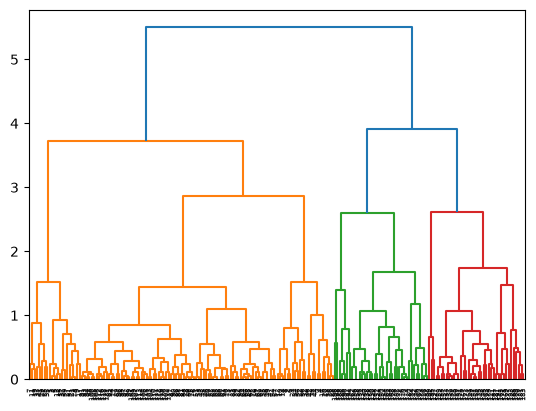

In [6]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

#### Penjelasan:
Kode di atas untuk menggambar dendrogram dari hasil clustering sebelumnya. Karena datanya ada 200 pelanggan, label di sumbu X jadi rapat dan tidak terbaca, tetapi yang perlu diperhatikan adalah bentuk cabangnya.

Dendrogram ini otomatis diberi warna dan terbagi menjadi tiga kelompok utama, yaitu oranye, hijau, dan merah. Pembagian ini membantu melihat segmentasi pelanggan, misalnya pelanggan dengan pengeluaran rendah, sedang, dan tinggi, sehingga mall bisa memberikan penawaran yang lebih sesuai untuk setiap kelompok.

Semakin tinggi sebuah cabang bertemu, semakin berbeda kelompok yang digabungkan. Kalau dendrogram dipotong secara mendatar pada ketinggian tertentu, jumlah garis yang terpotong adalah jumlah klaster yang terbentuk.

## Tugas
Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram **single linkage** dengan **complete linkage** dan **average linkage**.

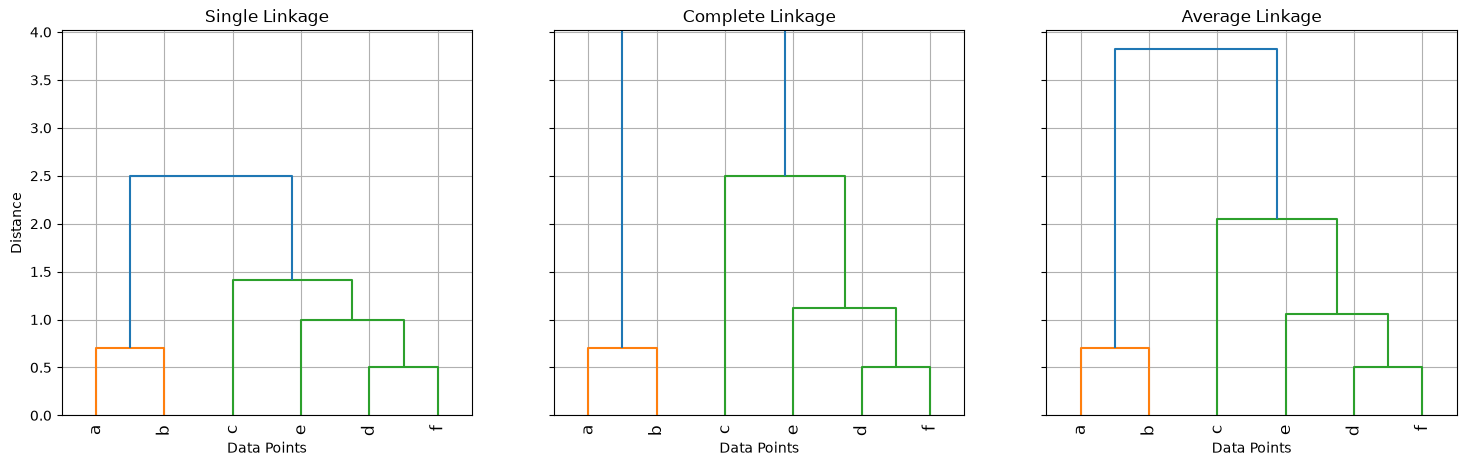

In [7]:
# Dataset sederhana dari percobaan 1
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5]  # f
])
labels = ['a', 'b', 'c', 'd', 'e', 'f']

# Tiga metode linkage yang dibandingkan
methods = ['single', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, method in zip(axes, methods):
    linked = linkage(data, method=method)
    dendrogram(linked, labels=labels, leaf_rotation=90, ax=ax)
    ax.set_title(f"{method.capitalize()} Linkage")
    ax.set_xlabel("Data Points")
    ax.grid(True)

axes[0].set_ylabel("Distance")
plt.show()

#### Penjelasan:
Kode di atas untuk membandingkan tiga metode linkage (single, complete, dan average) pada dataset sederhana yang sama. Ketiganya digambar berdampingan dalam satu gambar dengan `plt.subplots(1, 3, ...)`, dan `sharey=True` dipakai supaya skala sumbu Y sama sehingga tinggi cabangnya bisa dibandingkan langsung.

Perbedaan ketiga metode ada pada cara menghitung jarak antar klaster. Single linkage memakai jarak terdekat antar anggota dua klaster, complete linkage memakai jarak terjauh, dan average linkage memakai rata-rata dari semua jarak antar anggota.

Dari grafiknya terlihat bahwa urutan penggabungannya sama pada ketiga metode, yaitu d dengan f, lalu a dengan b, lalu e bergabung ke kelompok {d,f}, lalu c bergabung ke kelompok {e,d,f}, dan terakhir kelompok {a,b} bergabung dengan kelompok {c,d,e,f}. Karena urutannya sama, bentuk pohonnya mirip. Yang berbeda adalah ketinggian penggabungannya.

Dua penggabungan pertama jaraknya sama persis pada ketiga metode, yaitu 0.5 untuk d dengan f dan 0.7071 untuk a dengan b. Hal ini terjadi karena yang digabung masih berupa satu titik, sehingga jarak terdekat, terjauh, dan rata-ratanya tidak berbeda.

Mulai penggabungan berikutnya, perbedaannya mulai terlihat. Single linkage menghasilkan cabang paling rendah karena hanya melihat jarak terdekat, sehingga titik-titik mudah tersambung satu per satu. Pada metode ini e bergabung di jarak 1.0, c bergabung di 1.4142, dan penggabungan terakhir hanya di jarak 2.5.

Complete linkage menghasilkan cabang paling tinggi karena melihat jarak terjauh. Pada metode ini e bergabung di jarak 1.1180, c bergabung di 2.5, dan penggabungan terakhir sampai di 5.6569, yaitu jarak titik a ke titik c.

Average linkage ada di tengah-tengah. Pada metode ini e bergabung di jarak 1.0590, c bergabung di 2.0501, dan penggabungan terakhir di 3.8259.

Kesimpulannya, ketiga metode sama-sama memisahkan kelompok {a,b} dari kelompok {c,d,e,f}, tetapi tinggi cabangnya berbeda, yaitu single paling rendah, average di tengah, dan complete paling tinggi. Single linkage cocok untuk klaster yang bentuknya memanjang, complete linkage cocok untuk klaster yang padat dan terpisah jelas, sedangkan average linkage menjadi pilihan yang seimbang di antara keduanya.